In [3]:
#read merged investors_csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Combined_09_12_24.csv")


from matplotlib.colors import LinearSegmentedColormap
sunset_orange_blue = LinearSegmentedColormap.from_list(
    "sunset_orange_blue",
    ["#F26B38", "#F7C99E", "#0067A3"],  # orange → sand → blue
)



In [ ]:
Q1- “Do individuals tend to overestimate or underestimate their financial knowledge relative to their actual financial literacy level?”
OR Do individuals tend to overestimate or underestimate their financial knowledge, and are there systematic patterns of over- or underestimation across different levels of actual financial literacy?

Answer: Individuals tend to overestimate their financial knowledge, especially those with lower actual financial literacy levels. 
The overestimation is more pronounced among individuals with lower literacy scores, while those with higher literacy levels tend 
to have a more accurate self-assessment.

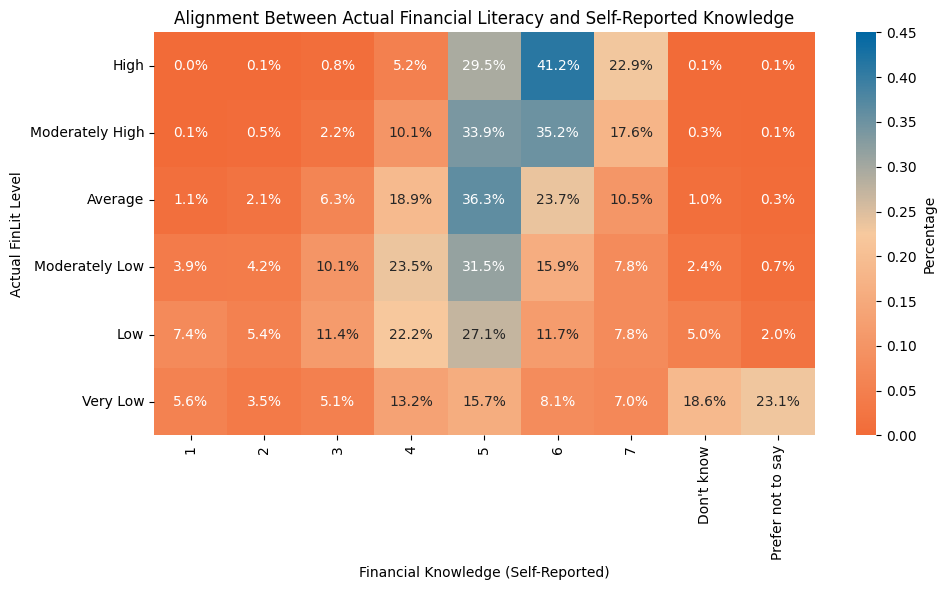

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

# Your new color palette
sunset_orange_blue = LinearSegmentedColormap.from_list(
    "sunset_orange_blue",
    ["#F26B38", "#F7C99E", "#0067A3"]  # orange → sand → blue
)

order = ["High", "Moderately High", "Average", "Moderately Low", "Low", "Very Low"]

# Crosstab of FinLit_Level vs Financial Knowledge
cross_knowledge = pd.crosstab(df['FinLit_Level'], df['Financial Knowledge'], normalize='index')

# Reorder the rows (FinLit_Level)
cross_knowledge = cross_knowledge.reindex(order)

# Plot heatmap with fixed color range
plt.figure(figsize=(10,6))
ax = sns.heatmap(
    cross_knowledge,
    cmap=sunset_orange_blue,
    annot=True,
    fmt=".1%",
    cbar_kws={'label': 'Percentage'},
    vmin=0.0,    # Minimum of color scale
    vmax=0.45    # Maximum of color scale
)

# Adjust colorbar ticks
cbar = ax.collections[0].colorbar
ticks = list(cbar.get_ticks())
if 0.0 not in ticks:
    ticks = [0.0] + ticks
if 0.45 not in ticks:
    ticks.append(0.45)
cbar.set_ticks(ticks)
cbar.set_ticklabels([f"{t:.2f}" for t in ticks])

plt.title("Alignment Between Actual Financial Literacy and Self-Reported Knowledge")
plt.xlabel("Financial Knowledge (Self-Reported)")
plt.ylabel("Actual FinLit Level")
plt.tight_layout()
plt.show()


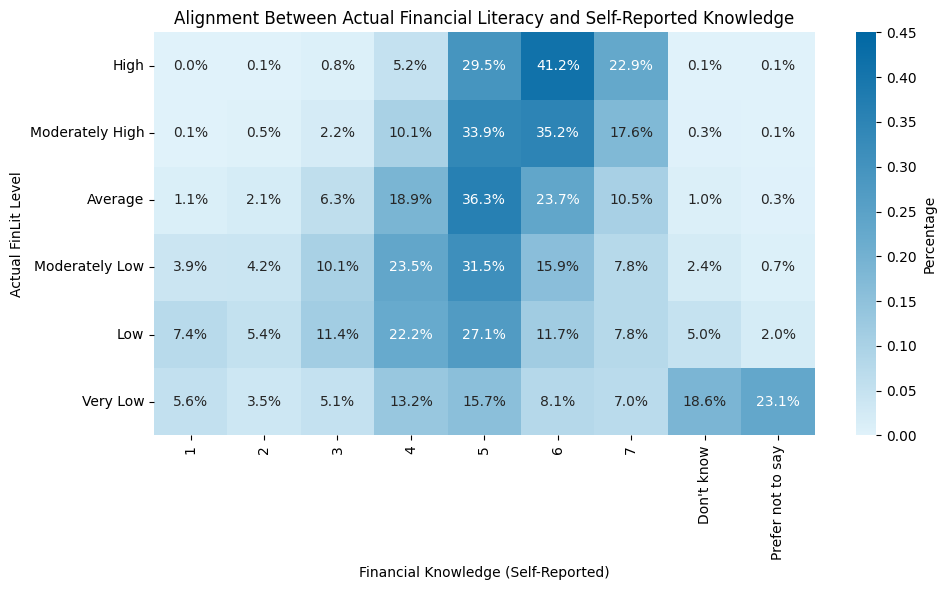

In [23]:
plt.figure(figsize=(10,6))
ax = sns.heatmap(
    cross_knowledge,
    cmap=blue_gradient,
    annot=True,
    fmt=".1%",
    cbar_kws={'label': 'Percentage'},
    vmin=0.0,   # Set the minimum of the color scale
    vmax=0.45   # Set the maximum of the color scale
)

# Adjust colorbar ticks
cbar = ax.collections[0].colorbar
ticks = list(cbar.get_ticks())
if 0.0 not in ticks:
    ticks = [0.0] + ticks
if 0.45 not in ticks:
    ticks.append(0.45)
cbar.set_ticks(ticks)
cbar.set_ticklabels([f"{t:.2f}" for t in ticks])

plt.title("Alignment Between Actual Financial Literacy and Self-Reported Knowledge")
plt.xlabel("Financial Knowledge (Self-Reported)")
plt.ylabel("Actual FinLit Level")
plt.tight_layout()
plt.show()


In [ ]:
Q2- "Based on the distribution of acutal scores, how reliable is self-reported financial confidence as a measure of true financial literacy?"
Answer: Self-reported financial confidence is a moderately reliable measure of true financial literacy. There is a positive correlation between financial confidence and actual literacy scores, indicating that individuals with higher literacy levels tend to report higher confidence. However, the relationship is not perfect, as some individuals with lower literacy

C:\Users\annaw\AppData\Local\Temp\ipykernel_18192\727438527.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


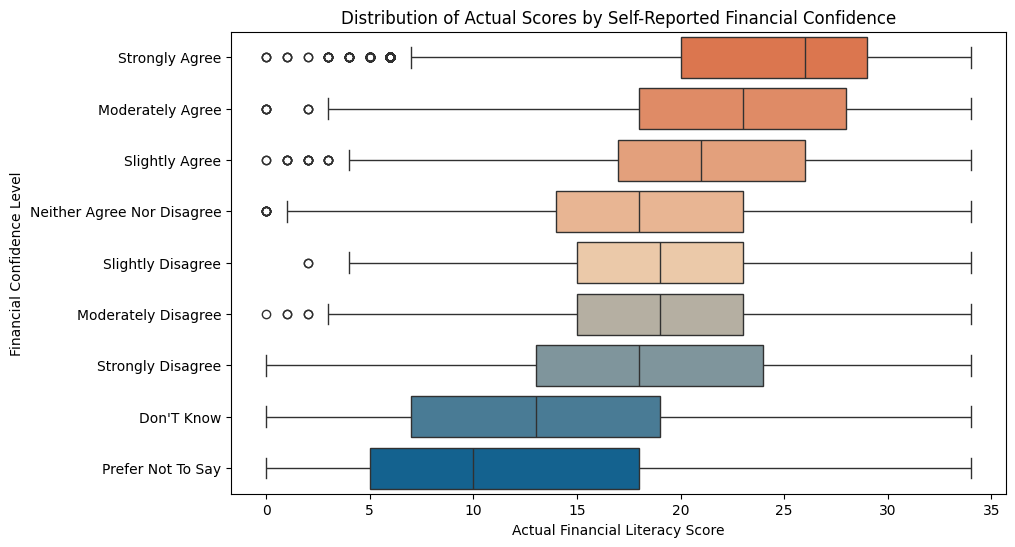

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# 1. Define your custom colormap
sunset_orange_blue = LinearSegmentedColormap.from_list(
    "sunset_orange_blue",
    ["#F26B38", "#F7C99E", "#0067A3"]  # orange → sand → blue
)

# 2. Clean and rename categories in 'Financial Confidence'
# Strip spaces
df['Financial Confidence'] = df['Financial Confidence'].str.strip()

# Replace common problematic names
rename_dict = {
    "Strongerly Disagree": "Strongly Disagree",
}

df['Financial Confidence'] = df['Financial Confidence'].replace(rename_dict)

# Standardize capitalization
df['Financial Confidence'] = df['Financial Confidence'].str.title()

# 3. Define the desired order (top to bottom)
confidence_order = [
    "Strongly Agree",
    "Moderately Agree",
    "Slightly Agree",
    "Neither Agree Nor Disagree",
    "Slightly Disagree",
    "Moderately Disagree",
    "Strongly Disagree",
    "Don'T Know",
    "Prefer Not To Say"
]

# 4. Sample colors from the colormap for each category
n_categories = len(confidence_order)
colors = [sunset_orange_blue(i/(n_categories-1)) for i in range(n_categories)]

# 5. Plot horizontal boxplot
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    y='Financial Confidence',
    x='Total_Score',
    order=confidence_order,
    palette=colors
)

# 6. Add labels and title
plt.title("Distribution of Actual Scores by Self-Reported Financial Confidence")
plt.xlabel("Actual Financial Literacy Score")
plt.ylabel("Financial Confidence Level")
plt.show()
